In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import learning_curve

In [42]:
df = pd.read_csv("data/car_evaluation.tsv", sep='\t')
df

,buying_price,maintenance_costs,doors,seats,luggage_boot,safety,target
0,3,3,0,0,0,0,0
1,3,3,0,0,0,1,0
2,3,3,0,0,0,2,0
3,3,3,0,0,1,0,0
4,3,3,0,0,1,1,0
...,...,...,...,...,...,...,...
1723,0,0,3,2,1,1,2
1724,0,0,3,2,1,2,3
1725,0,0,3,2,2,0,0
1726,0,0,3,2,2,1,2


In [43]:
x_col = len(df.columns[:-1])

In [44]:
X = df.iloc[:, 0:x_col].values
print(X)

[[3 3 0 0 0 0]
 [3 3 0 0 0 1]
 [3 3 0 0 0 2]
 ...
 [0 0 3 2 2 0]
 [0 0 3 2 2 1]
 [0 0 3 2 2 2]]


In [45]:
y = df.iloc[:, -1].values
print(y)

[0 0 0 ... 0 2 3]


In [46]:
imputer = SimpleImputer(strategy='mean')
imputer = imputer.fit(X[:, 0:x_col])
X[:, 0:x_col] = imputer.transform(X[:, 0:x_col])

In [47]:
print(X)

[[3 3 0 0 0 0]
 [3 3 0 0 0 1]
 [3 3 0 0 0 2]
 ...
 [0 0 3 2 2 0]
 [0 0 3 2 2 1]
 [0 0 3 2 2 2]]


In [48]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(y)

[0 0 0 ... 0 2 3]


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)

In [50]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1382, 6)
(346, 6)
(1382,)
(346,)


In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

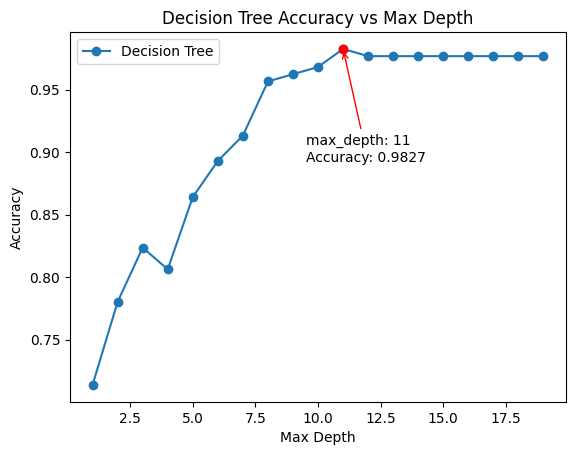

In [52]:
accuracy = {}
best_acc = 0
best_pred = 0
for i in range(1, 20):
    model = DecisionTreeClassifier(random_state=42, max_depth=i, criterion='entropy')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy[i] = accuracy_score(y_test, y_pred)
    if accuracy[i] > best_acc:
        best_acc = accuracy[i]
        best_pred = y_pred
max_depth = max(accuracy, key=accuracy.get)
best_acc = accuracy[max_depth]

plt.plot(list(accuracy.keys()), list(accuracy.values()), marker='o', label='Decision Tree')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.scatter(max_depth, best_acc, color='red', zorder=5)
plt.annotate(f'max_depth: {max_depth}\nAccuracy: {best_acc:.4f}', xy=(max_depth, best_acc), xytext=(max_depth - 1.5, best_acc - 0.09), arrowprops=dict(arrowstyle='->', color='red'))

plt.savefig('Figure/decision_tree_accuracy.pdf')
plt.show()

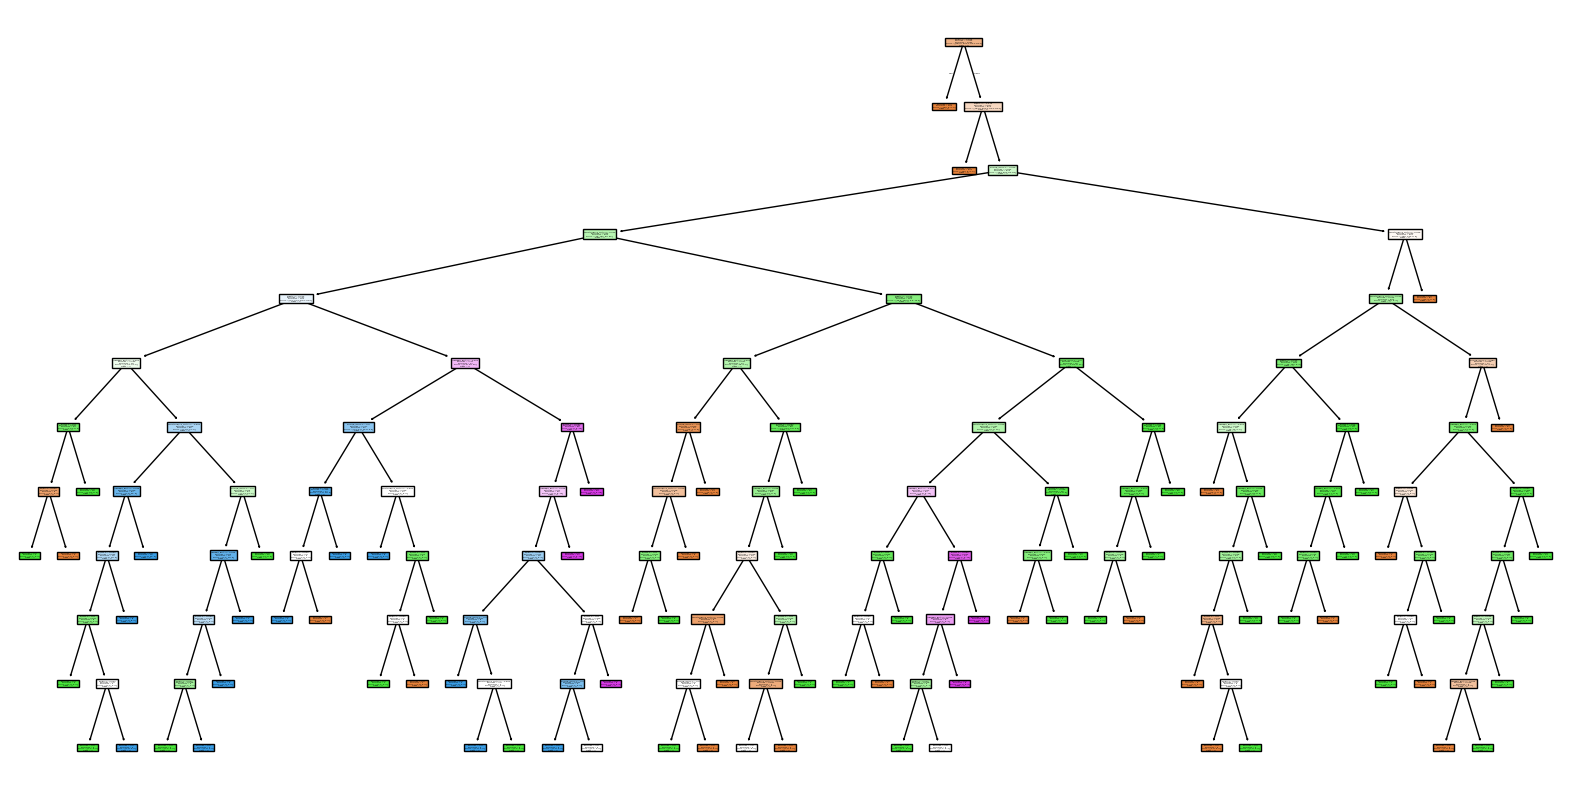

In [53]:
# plot tree on best max_depth
from sklearn.tree import plot_tree
best_model = DecisionTreeClassifier(random_state=42, max_depth=max_depth, criterion='entropy')
best_model.fit(X_train_scaled, y_train)
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    filled=True,
    feature_names=df.columns[:-1].astype(str),
    class_names=[str(c) for c in le.classes_]
)
plt.savefig('Figure/decision_tree_plot.pdf')
plt.show()

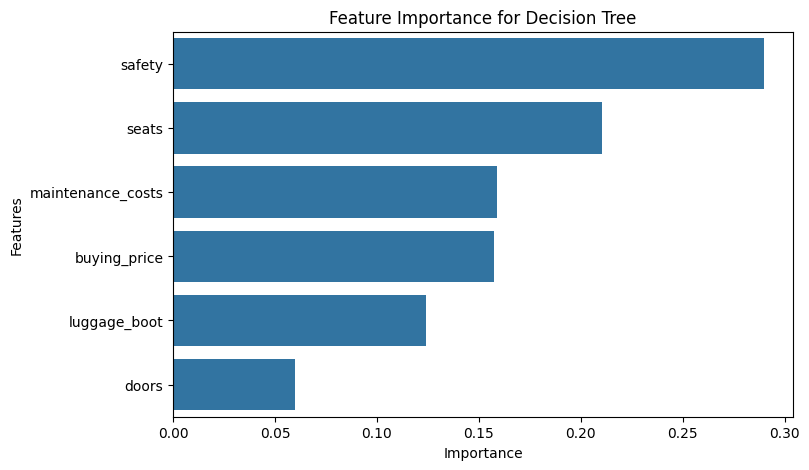

In [54]:
feature_importance = pd.Series(best_model.feature_importances_, index=df.columns[:-1])
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Feature Importance for Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('Figure/decision_tree_feature_importance.pdf')
plt.show()

In [ ]:
cm = confusion_matrix(y_test, best_pred)

print("Accuracy:", accuracy_score(y_test, best_pred))

report = classification_report(y_test, best_pred)
print(report)



Accuracy: 0.9826589595375722
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       247
           1       0.99      0.95      0.97        79
           2       0.83      1.00      0.91        10
           3       1.00      1.00      1.00        10

    accuracy                           0.98       346
   macro avg       0.95      0.99      0.97       346
weighted avg       0.98      0.98      0.98       346



In [56]:
cm

array([[245,   1,   1,   0],
       [  3,  75,   1,   0],
       [  0,   0,  10,   0],
       [  0,   0,   0,  10]])

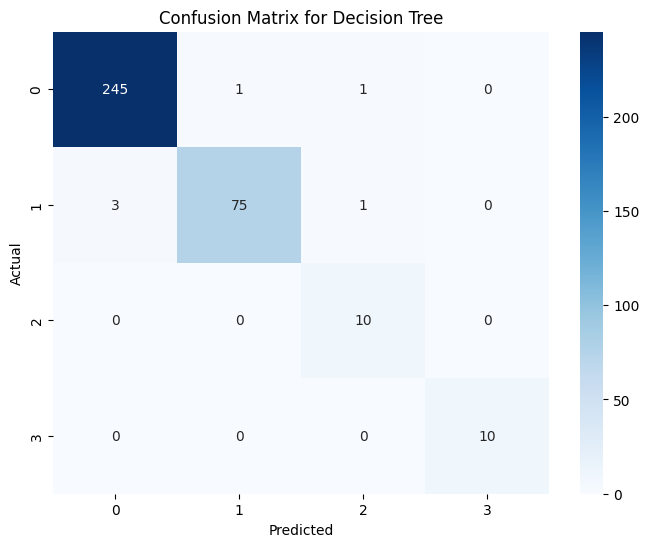

In [57]:
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix for Decision Tree")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Figure/decision_tree_confusion_matrix.pdf')
plt.show()

# Random Forest

In [65]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred2 = model.predict(X_test_scaled)

In [ ]:
cm2 = confusion_matrix(y_test, y_pred2)
print("Accuracy:", accuracy_score(y_test, y_pred2))
report2 = classification_report(y_test, y_pred2)
print(report2)
Random Forest

Accuracy: 0.9855491329479769
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       247
           1       0.96      0.97      0.97        79
           2       1.00      1.00      1.00        10
           3       1.00      0.90      0.95        10

    accuracy                           0.99       346
   macro avg       0.99      0.97      0.98       346
weighted avg       0.99      0.99      0.99       346



In [67]:
cm2

array([[245,   2,   0,   0],
       [  2,  77,   0,   0],
       [  0,   0,  10,   0],
       [  0,   1,   0,   9]])

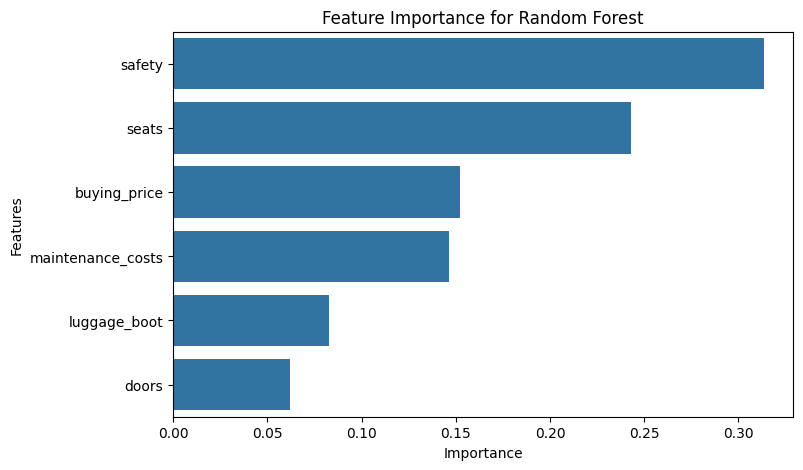

In [68]:
rf_feature_importance = pd.Series(model.feature_importances_, index=df.columns[:-1])
rf_feature_importance = rf_feature_importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=rf_feature_importance.values, y=rf_feature_importance.index)
plt.title('Feature Importance for Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('Figure/random_forest_feature_importance.pdf')
plt.show()

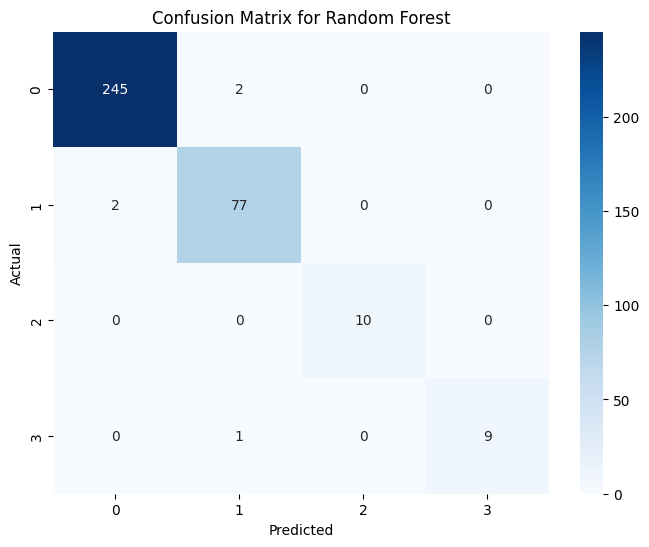

In [69]:
plt.figure(figsize=(8, 6))
plt.title('Confusion Matrix for Random Forest')
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Figure/random_forest_confusion_matrix.pdf')
plt.show()

In [70]:

report_dt = classification_report(y_test, best_pred, output_dict=True)
report_rf = classification_report(y_test, y_pred2, output_dict=True)
comparison = pd.DataFrame({
    'Decision Tree': [report_dt['0']['precision'], report_dt['0']['recall'], report_dt['0']['f1-score'], report_dt['accuracy']],
    'Random Forest': [report_rf['0']['precision'], report_rf['0']['recall'], report_rf['0']['f1-score'], report_rf['accuracy']]
}, index=['Precision', 'Recall', 'F1-Score', 'Accuracy'])

comparison = comparison.round(4)
comparison


,Decision Tree,Random Forest
Precision,0.9879,0.9919
Recall,0.9919,0.9919
F1-Score,0.9899,0.9919
Accuracy,0.9827,0.9855
